In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs_trading.data.loaders import load_prices
from pairs_trading.config import SplitConfig
from pairs_trading.models.ols_hedge import OLSHedge
from pairs_trading.signals.zscore import rolling_zscore, generate_signal
from pairs_trading.backtest.engine import BacktestEngine

First let's build a dataframe containing all the tickers that we want to test. Split between train and test sets.

In [ ]:
tickers = ["IAU", "GDX", "GLD", "SLV", "XLF", "KBE", "SPY", "IVV"]
df_train = load_prices(tickers, SplitConfig.train_start, SplitConfig.train_end, refresh=True)
df_test = load_prices(tickers, SplitConfig.val_start, SplitConfig.val_end, refresh=True)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


Run the training-testing pipeline on all 4 pairs and return the resulting metrics

In [11]:
pairs = [["IAU", "GDX"],["GLD", "SLV"], ["XLF", "KBE"], ["SPY", "IVV"]]

Final test results for IAU vs GDX:
sharpe: 0.5746117532605372
max_drawdown: 0.07952318956717618
hit_rate: 0.4772727272727273
average_holding_period: 14.642857142857142
n_trades: 14
----------------------------------------


Final test results for GLD vs SLV:
sharpe: 0.12421486212342313
max_drawdown: 0.6412845130850413
hit_rate: 0.4767025089605735
average_holding_period: 20.384615384615383
n_trades: 13
----------------------------------------


Final test results for XLF vs KBE:
sharpe: 0.27202631865179117
max_drawdown: 0.07802188086720349
hit_rate: 0.45660377358490567
average_holding_period: 17.857142857142858
n_trades: 14
----------------------------------------


Final test results for SPY vs IVV:
sharpe: -3.3986070177047187
max_drawdown: 0.03873938531231002
hit_rate: 0.37735849056603776
average_holding_period: 3.2916666666666665
n_trades: 25
----------------------------------------




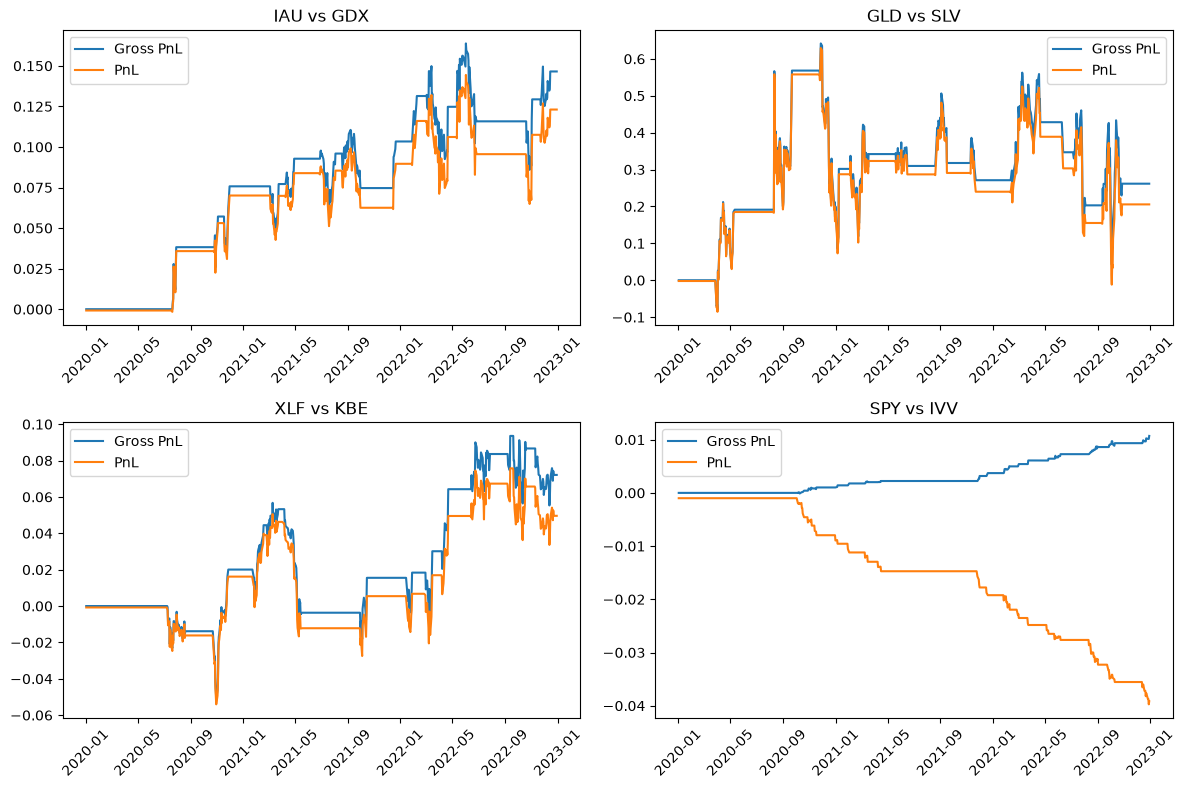

In [13]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):
    hedge = OLSHedge()
    hedge.fit(df_train[y], df_train[x])
    residuals = hedge.spread(df_test[y], df_test[x])
    zscores = rolling_zscore(residuals)
    signals = generate_signal(zscores)
    hedge_ratios = pd.Series(hedge.beta, index=signals.index)
    engine = BacktestEngine()
    result = engine.run(df_test[y], df_test[x], signals, hedge_ratios)
    print(f"Final test results for {y} vs {x}:")
    for key, value in result.metrics.items():
        print(f"{key}: {value}")
    print("-"*40)
    print("\n")
    axs[i].plot(result.gross_pnl.cumsum(), label="Gross PnL")
    axs[i].plot(result.pnl.cumsum(), label="PnL")
    axs[i].legend()
    axs[i].set_title(f"{y} vs {x}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
